## ESM-GCN vs ESM-GCN_BE

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_log_file(metrics_csv_be, metrics_csv_b, metrics_csv_e, coords, metrics_img):
    df_be = pd.read_csv(metrics_csv_be)
    df_b = pd.read_csv(metrics_csv_b)
    df_e = pd.read_csv(metrics_csv_e)

    sns.set_theme(style="darkgrid")
    fig, ((ax_tr_be, ax_tr), (ax_te_be, ax_te)) = plt.subplots(2, 2, figsize=(16, 9))  # 1 rows, 2 columns
    fontsize = 16

    # Plot 1: Training BE Metrics
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr_be.tick_params(axis='x', bottom=False, labelbottom=False)    
    ax_tr_be.set_xlim(-50, 1050)
    ax_tr_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_tr_be.tick_params(axis='y', labelsize=fontsize)
    ax_tr_be.set_ylim(-0.1, 1.3)
    ax_tr_be.legend(title='Training (Combined)', loc='upper right', frameon=False)

    # Plot 2: Testing BE Metrics
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te_be.set_xlabel('Epochs', fontsize=fontsize)
    ax_te_be.tick_params(axis='x', labelsize=fontsize)
    ax_te_be.set_xlim(-50, 1050)
    ax_te_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_te_be.tick_params(axis='y', labelsize=fontsize)
    ax_te_be.set_ylim(-0.1, 1.3)
    ax_te_be.legend(title='Testing (Combined)', loc='upper right', frameon=False)

    # Plot 3: Training Metrics
    ax_tr.plot(df_b['Epoch'], df_b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr.plot(df_e['Epoch'], df_e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr.tick_params(axis='x', bottom=False, labelbottom=False)   
    ax_tr.set_xlim(-50, 1050)
    ax_tr.tick_params(axis='y', left=False, labelleft=False)
    ax_tr.set_ylim(-0.1, 1.3)
    ax_tr.legend(title='Training (Separate)', loc='upper right', frameon=False)

    # Plot 4: Testing Metrics
    ax_te.plot(df_b['Epoch'], df_b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te.plot(df_e['Epoch'], df_e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te.set_xlabel('Epochs', fontsize=fontsize)
    ax_te.tick_params(axis='x', labelsize=fontsize)
    ax_te.set_xlim(-50, 1050)
    ax_te.tick_params(axis='y', left=False, labelleft=False)
    ax_te.set_ylim(-0.1, 1.3)
    ax_te.legend(title='Testing (Separate)', loc='upper right', frameon=False)

    # Plot Best Test Loss
    best_df_be_b_rmse = find_best_epoch(metrics_csv_be, f'Test Binding RMSE')
    best_df_be_e_rmse = find_best_epoch(metrics_csv_be, f'Test Expression RMSE')
    best_df_b_rmse = find_best_epoch(metrics_csv_b, f'Test RMSE')
    best_df_e_rmse = find_best_epoch(metrics_csv_e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"\tBE Binding: epoch {best_df_be_b_rmse[0]}, rmse {best_df_be_b_rmse[1]:.4f}")
    print(f"\tBE Expression: epoch {best_df_be_e_rmse[0]}, rmse {best_df_be_e_rmse[1]:.4f}")
    print(f"\tBinding: epoch {best_df_b_rmse[0]}, rmse {best_df_b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df_e_rmse[0]}, rmse {best_df_e_rmse[1]:.4f}")

    ax_te_be.annotate(
        f'({best_df_be_b_rmse[0]}, {best_df_be_b_rmse[1]:.4f})', best_df_be_b_rmse, 
        textcoords="offset points", xytext=(coords['BE Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te_be.annotate(
        f'({best_df_be_e_rmse[0]}, {best_df_be_e_rmse[1]:.4f})', best_df_be_e_rmse, 
        textcoords="offset points", xytext=(coords['BE Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_b_rmse[0]}, {best_df_b_rmse[1]:.4f})', best_df_b_rmse, 
        textcoords="offset points", xytext=(coords['Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_e_rmse[0]}, {best_df_e_rmse[1]:.4f})', best_df_e_rmse, 
        textcoords="offset points", xytext=(coords['Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

Comparing: best ESM-GCN_BE binding and expression vs best ESM-GCN binding and best ESM-GCN expression.

Best test RMSE at epoch x:
	BE Binding: epoch 945, rmse 0.5117
	BE Expression: epoch 962, rmse 0.3218
	Binding: epoch 731, rmse 0.5189
	Expression: epoch 993, rmse 0.3161


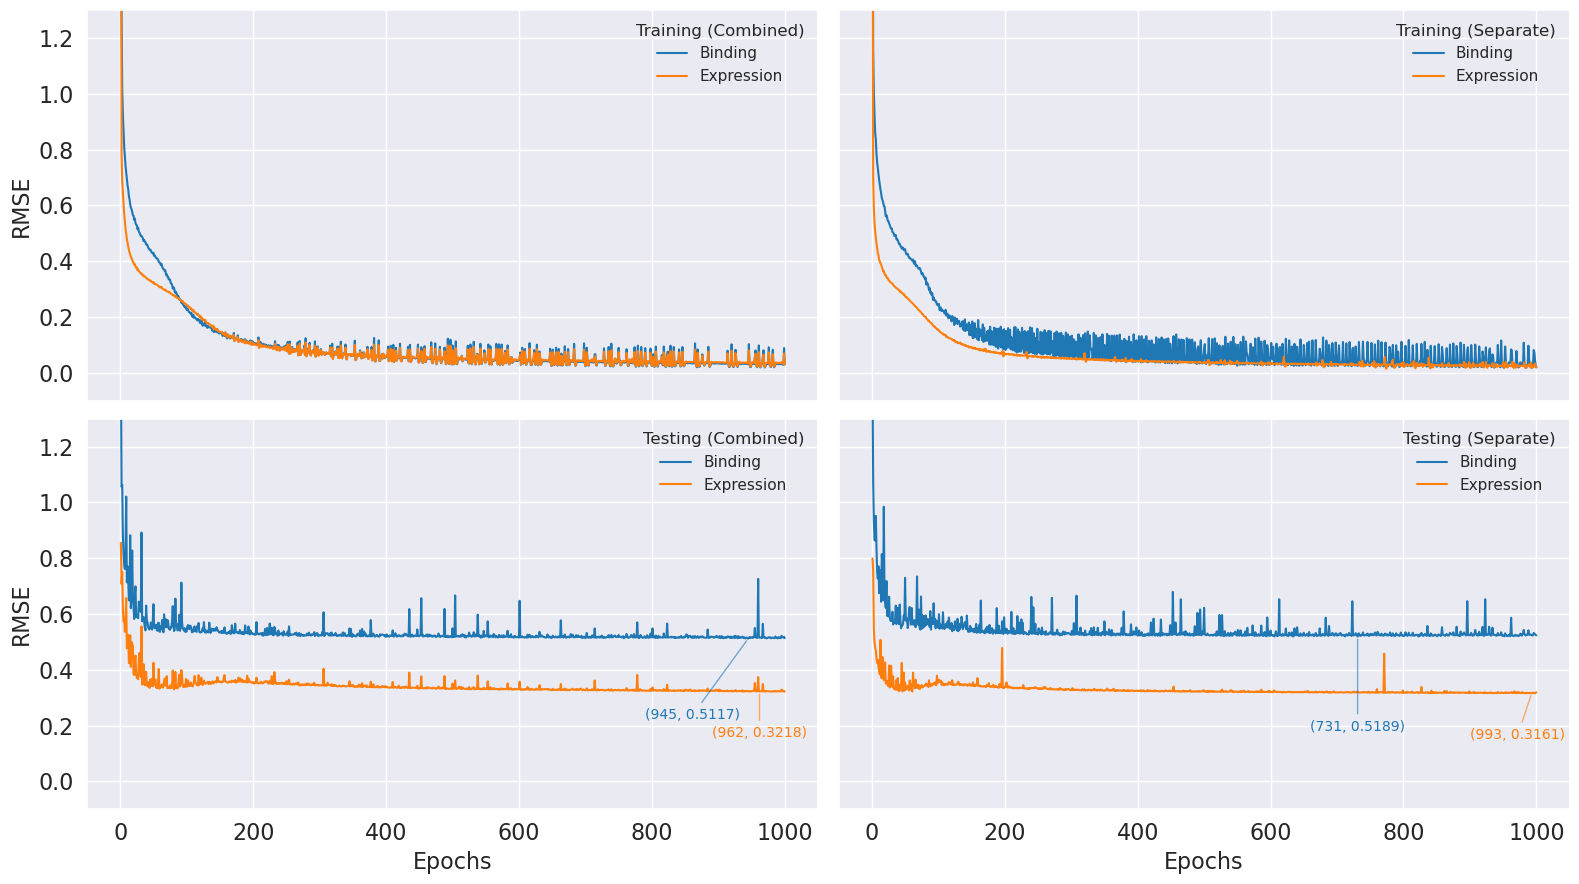

In [2]:
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-11_16-06/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-12_05-51/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-12_05-52/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"

coords = {
    "BE Binding": (-40,-50),
    "BE Expression": (0,-25),
    "Binding": (0,-60),
    "Expression": (-10,-25)
}

comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/best_esm-gcn_BE.vs.best_esm-gcn"
plot_comparative_log_file(be_adam_lr_1e_neg_5, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
## R^2 Values - Getting the predicted values
We need to get the R^2 values from all available ESM-GCN models. To do this, we need to get the predicted values from the best saved model.

In [8]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]
    
class DMSDataset_BE(Dataset):
    """ Binding and Expression DMS Dataset, multi target. """
    
    def __init__(self, csv_file:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding target,
        - expression target
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, binding target, expression target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df['ACE2-binding_affinity'][idx], self.full_df['RBD_expression'][idx]

/data/miniconda3/envs/spike_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Non BE Models

In [9]:
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels, fcn_num_layers):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # FCN layer(s)
        layers = []

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(hidden_channels, hidden_channels))
            layers.append(nn.ReLU())

        self.fcn = nn.Sequential(*layers)
        
        self.output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.fcn(x)
        output = self.output(x).squeeze(1)
        return output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, target in zip(esm_aa_embedding, targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()

                graphs.append(Data(
                    x=embedding, 
                    edge_index=edge_index,
                    y=torch.tensor([target], dtype=torch.float32)
                ))

            batch_graph = Batch.from_data_list(graphs).to(device)
            output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return output, batch_graph.y
    
# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "mse": [],
        "rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds, y = model(tokenized_seqs, targets)
        batch_losses = loss_fn(preds, y)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("train")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds, y = model(tokenized_seqs, targets)
            batch_losses = loss_fn(preds, y)

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("test")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [10]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
fcn_num_layers = 5
gcn = GraphSAGE(input_channels, hidden_channels, fcn_num_layers)

model = ESM_GCN(esm, gcn)

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

# Run
print("== BINDING ==")
result_tag = 'binding' 
run_dir_binding4 = os.path.join(results_dir, f'5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-binding-2025-01-30_03-16')
saved_model_pth_binding4 = os.path.join(run_dir_binding4, "best_saved_model.pth")

run_dir_binding5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28')
saved_model_pth_binding5 = os.path.join(run_dir_binding5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding4, saved_model_pth_binding4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding5, saved_model_pth_binding5)

print("== EXPRESSION ==")
result_tag = 'expression' 
run_dir_expression4 = os.path.join(results_dir, f'5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-expression-2025-01-30_03-14')
saved_model_pth_expression4 = os.path.join(run_dir_expression4, "best_saved_model.pth")

run_dir_expression5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10')
saved_model_pth_expression5 = os.path.join(run_dir_expression5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression4, saved_model_pth_expression4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression5, saved_model_pth_expression5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-binding-2025-01-30_03-16/best_saved_model.pth, saved at epoch 84, rmse loss 0.5477690168930749


Testing data: 100%|| 322/322 [00:18<00:00, 17.46it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28/best_saved_model.pth, saved at epoch 394, rmse loss 0.5455089224994019


Testing data: 100%|| 322/322 [00:18<00:00, 17.37it/s]


== EXPRESSION ==
>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-expression-2025-01-30_03-14/best_saved_model.pth, saved at epoch 137, rmse loss 0.3188883682994425


Testing data: 100%|| 322/322 [00:18<00:00, 17.50it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10/best_saved_model.pth, saved at epoch 64, rmse loss 0.3330981123004693


Testing data: 100%|| 322/322 [00:18<00:00, 17.48it/s]


### BE Models

In [11]:
class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels, fcn_num_layers):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # FCN layer(s)
        layers = []

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(hidden_channels, hidden_channels))
            layers.append(nn.ReLU())

        self.fcn = nn.Sequential(*layers)
        
        self.binding_output = nn.Linear(hidden_channels, 1)
        self.expression_output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.fcn(x)
        binding_output = self.binding_output(x).squeeze(1)
        expression_output = self.expression_output(x).squeeze(1)
        return binding_output, expression_output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, binding_targets, expression_targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, b_target, e_target in zip(esm_aa_embedding, binding_targets, expression_targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()
                graphs.append(Data(
                    x=embedding,
                    edge_index=edge_index,
                    y=torch.tensor([[b_target, e_target]], dtype=torch.float32)  # Add an extra dimension
                ))
            
            batch_graph = Batch.from_data_list(graphs).to(device)
            binding_output, expression_output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return binding_output, expression_output, batch_graph.y

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "binding_predicted_value":[],
        "expression_predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "binding_mse": [],
        "binding_rmse": [],
        "expression_mse": [],
        "expression_rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        binding_preds, expression_preds, y = model(tokenized_seqs, binding_targets, expression_targets)
        batch_binding_losses = loss_fn(binding_preds, y[:, 0])
        batch_expression_losses = loss_fn(expression_preds,  y[:, 1])
        batch_binding_loss = sum(batch_binding_losses)
        batch_expression_loss = sum(batch_expression_losses)
        batch_be_loss = batch_binding_loss + batch_expression_loss
        batch_be_loss.backward()

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("train")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            binding_preds, expression_preds, y = model(tokenized_seqs, binding_targets, expression_targets)
            batch_binding_losses = loss_fn(binding_preds, y[:, 0])
            batch_expression_losses = loss_fn(expression_preds,  y[:, 1])

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("test")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [12]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

run_dir_be4 = os.path.join(results_dir, f'5_relu-adam.lr0.0001.esm_gcn_BE-DMS_OLD-2025-01-30_03-18')
saved_model_pth_be4 = os.path.join(run_dir_be4, "best_saved_model.pth")

run_dir_be5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17')
saved_model_pth_be5 = os.path.join(run_dir_be5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"))
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"))
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
fcn_num_layers = 5
gcn = GraphSAGE(input_channels, hidden_channels, fcn_num_layers)

model = ESM_GCN(esm, gcn)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_be4, saved_model_pth_be4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_be5, saved_model_pth_be5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/best_saved_model.pth, saved at epoch 145, rmse loss 0.6260328610311541


Testing data: 100%|| 322/322 [00:19<00:00, 16.45it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17/best_saved_model.pth, saved at epoch 149, rmse loss 0.6574935181750767


Testing data: 100%|| 322/322 [00:19<00:00, 16.54it/s]


## R^2 Values - Getting the R^2 vales
Get WT locations.

In [13]:
import os
import pandas as pd

data_dir = "../../data/dms/original"
binding_df = pd.read_csv(os.path.join(data_dir, "binding_Kds.csv"), sep=',', header=0)
binding_df = binding_df.dropna(subset=['log10Ka']).reset_index(drop=True)
wildtype_b_df = binding_df[binding_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_b_df = wildtype_b_df[['target', 'variant_class', 'aa_substitutions', 'log10Ka']].copy()
wildtype_b_df['mean_log10Ka'] = wildtype_b_df.groupby('target')['log10Ka'].transform('mean')
binding_wt = wildtype_b_df['mean_log10Ka'][8] 

expression_df = pd.read_csv(os.path.join(data_dir, "expression_meanFs.csv"), sep=',', header=0)
expression_df = expression_df.dropna(subset=['ML_meanF']).reset_index(drop=True)
wildtype_e_df = expression_df[expression_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_e_df = wildtype_e_df[['target', 'variant_class', 'aa_substitutions', 'ML_meanF']].copy()
wildtype_e_df['mean_ML_meanF'] = wildtype_e_df.groupby('target')['ML_meanF'].transform('mean')
expression_wt = wildtype_e_df['mean_ML_meanF'][11]

print(f"WT binding: {binding_wt}, WT expression: {expression_wt}")

WT binding: 10.792732335537766, WT expression: 10.29234282907662


In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_predicted_value_scatter_with_threshold(merged_df, measured_df_col, predicted_df_col, title, save_as, wt_loc, threshold_percent=10):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 9))
    ax = plt.gca()
    fontsize = 20

    # Calculate R² for test data
    test_all_df = merged_df[merged_df['mode'] == 'test']
    r2_value = r2_score(test_all_df[measured_df_col], test_all_df[predicted_df_col])
    print(f"R^2: {r2_value}")

    # Calculate the threshold as 10% of measured values
    merged_df['threshold'] = merged_df[measured_df_col] * (threshold_percent/100)
    merged_df['abs_diff'] = np.abs(merged_df[measured_df_col] - merged_df[predicted_df_col])
    
    # Separate data based on the relative threshold
    within_threshold = merged_df[merged_df['abs_diff'] <= merged_df['threshold']]
    outside_threshold = merged_df[merged_df['abs_diff'] > merged_df['threshold']]

    test_outside_df = outside_threshold[outside_threshold['mode'] == 'test']
    r2_outside_value = r2_score(test_outside_df[measured_df_col], test_outside_df[predicted_df_col])
    print(f"R^2 outside of threshold: {r2_outside_value}")

    test_inside_df = within_threshold[within_threshold['mode'] == 'test']
    r2_inside_value = r2_score(test_inside_df[measured_df_col], test_inside_df[predicted_df_col])
    print(f"R^2 inside of threshold: {r2_inside_value}")

    # Plot train and test data within threshold
    test_df = within_threshold[within_threshold['mode'] == 'test']
    sns.scatterplot(
        x=test_df[measured_df_col],
        y=test_df[predicted_df_col],
        color="tab:orange",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Test =<10%"
    )

    train_df = within_threshold[within_threshold['mode'] == 'train']
    sns.scatterplot(
        x=train_df[measured_df_col],
        y=train_df[predicted_df_col],
        color="tab:blue",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Train =<10%"
    )

    # Plot train and test data outside threshold (greyed out)
    sns.scatterplot(
        data=outside_threshold,
        x=measured_df_col,
        y=predicted_df_col,
        color="gray",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label=">10%"
    )

    # Add vertical line wildtype loc
    plt.axvline(x=wt_loc, color='black', linestyle='-', linewidth=2)
    plt.text(wt_loc, 5.2, 'wt', 
            verticalalignment='bottom',
            horizontalalignment='center',
            fontsize=fontsize-4)

    plt.xlim(5.5, 11.5)
    plt.ylim(5.5, 11.5)
    plt.xlabel(f"Measured {measured_df_col}", fontsize=fontsize)
    plt.ylabel(f"Predicted {measured_df_col}", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f"{title}\nR² = {r2_value:.4f}", fontsize=fontsize)
    plt.legend(loc="upper left", title="Threshold=0.1", markerscale=1.75, fontsize=fontsize-6, title_fontsize=fontsize-4)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')
    plt.tight_layout()
    plt.show()

    return r2_value

### Non BE - LR = 1e-04

R^2: 0.9174951939023579
R^2 outside of threshold: -0.5875876717374944
R^2 inside of threshold: 0.9870408059181133


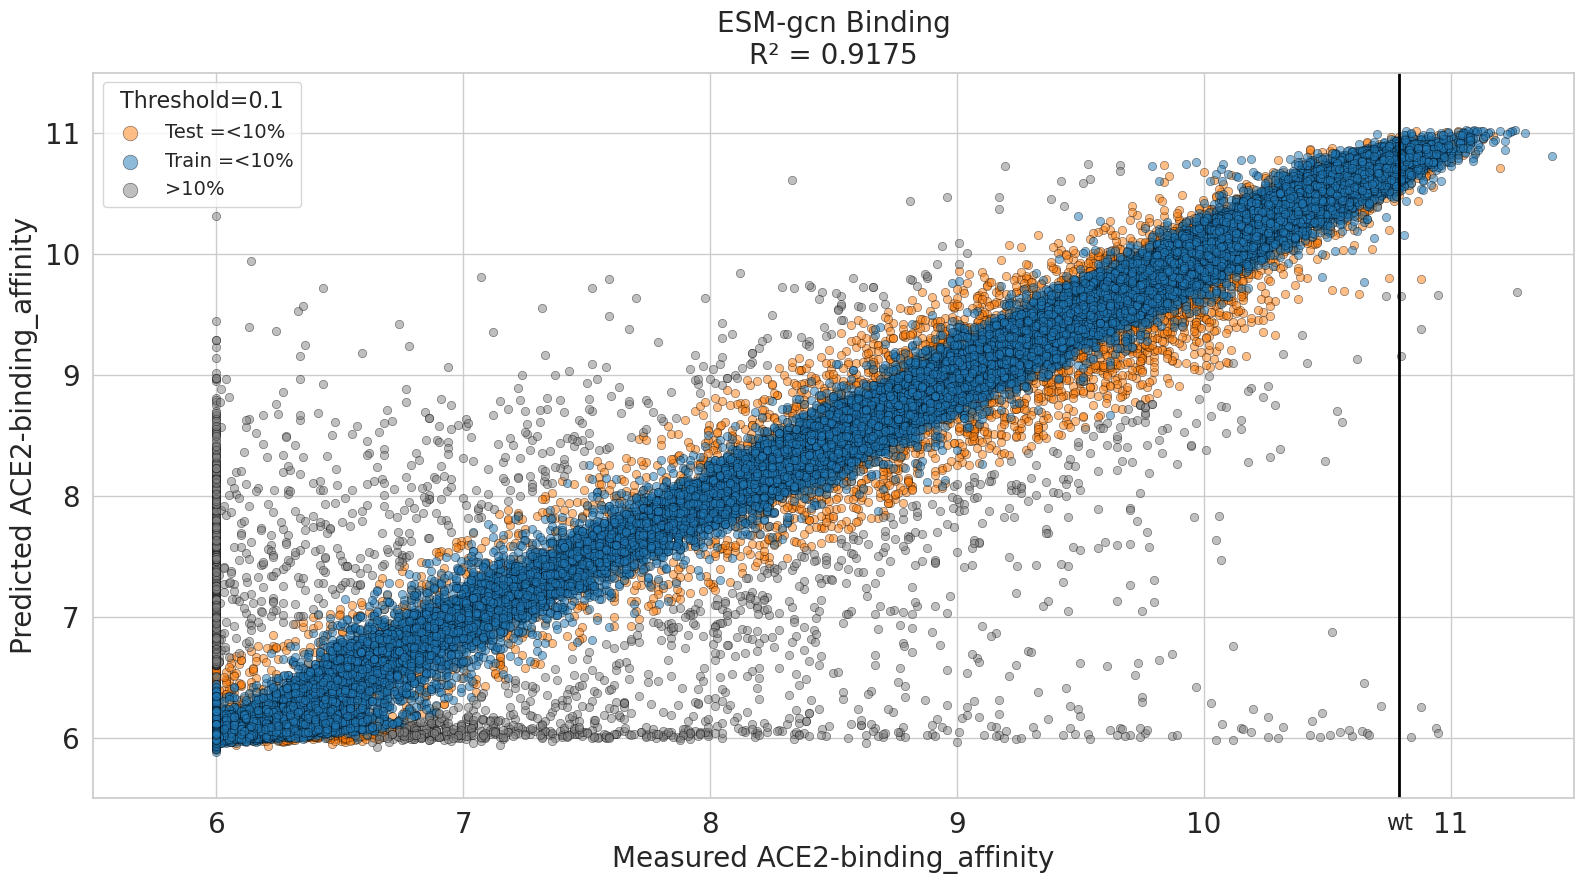

R^2: 0.8977509734441381
R^2 outside of threshold: -0.2193094098008641
R^2 inside of threshold: 0.9248052838756294


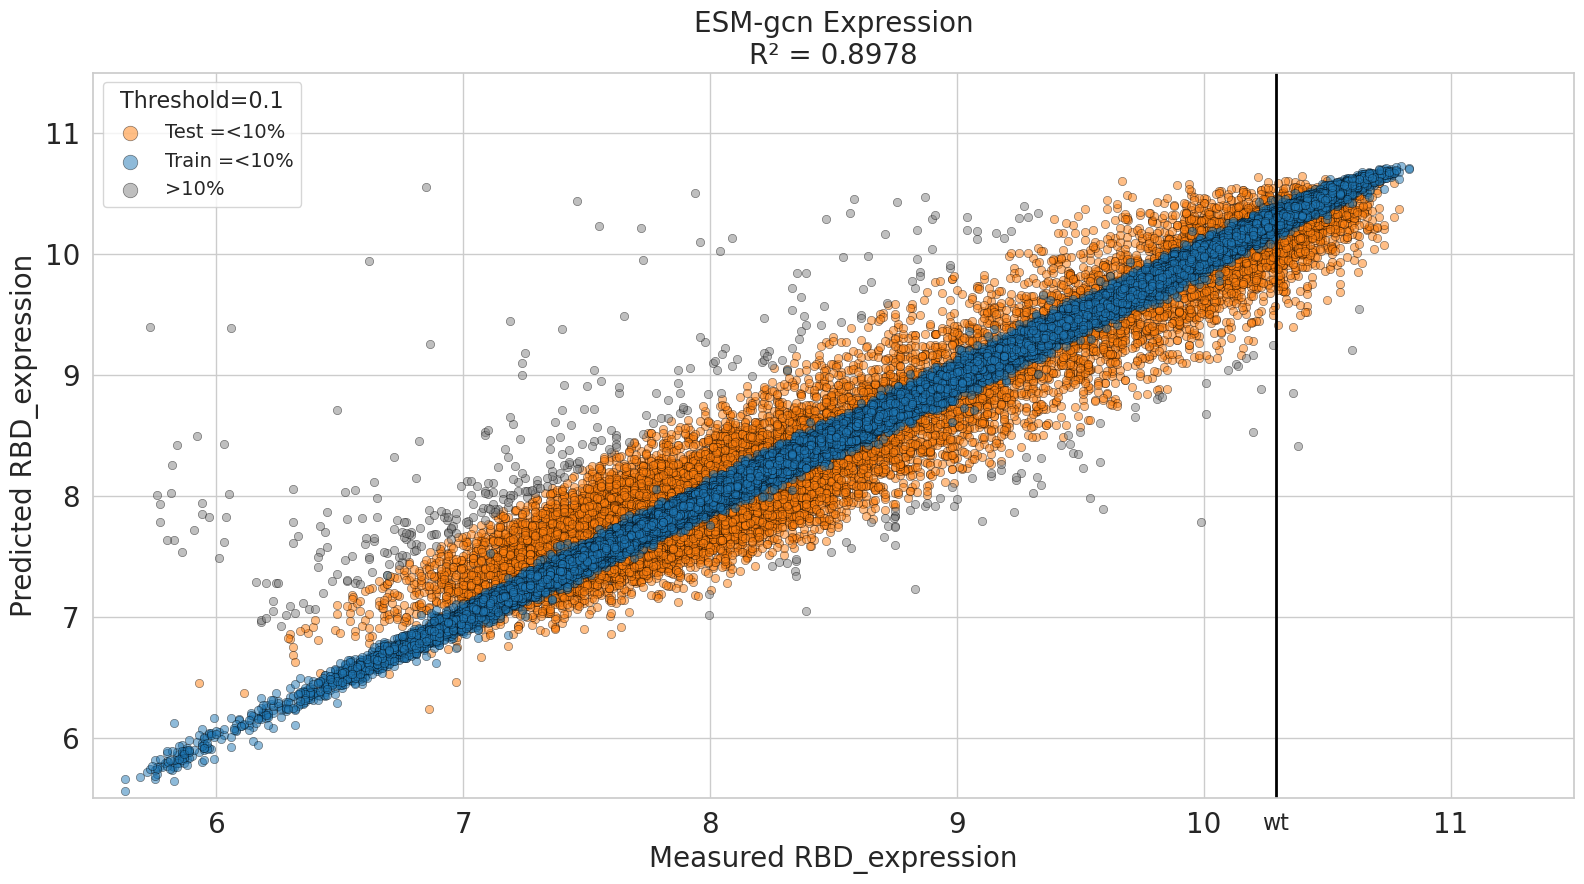

In [15]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-binding-2025-01-30_03-16/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-gcn Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn.lr1e-04.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn-DMS_OLD-expression-2025-01-30_03-14/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-gcn Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn.lr1e-04.expression-scatter.pdf", expression_wt)

### Non BE - LR = 1e-05

R^2: 0.9181746208985173
R^2 outside of threshold: -0.6435941969047878
R^2 inside of threshold: 0.986591418565855


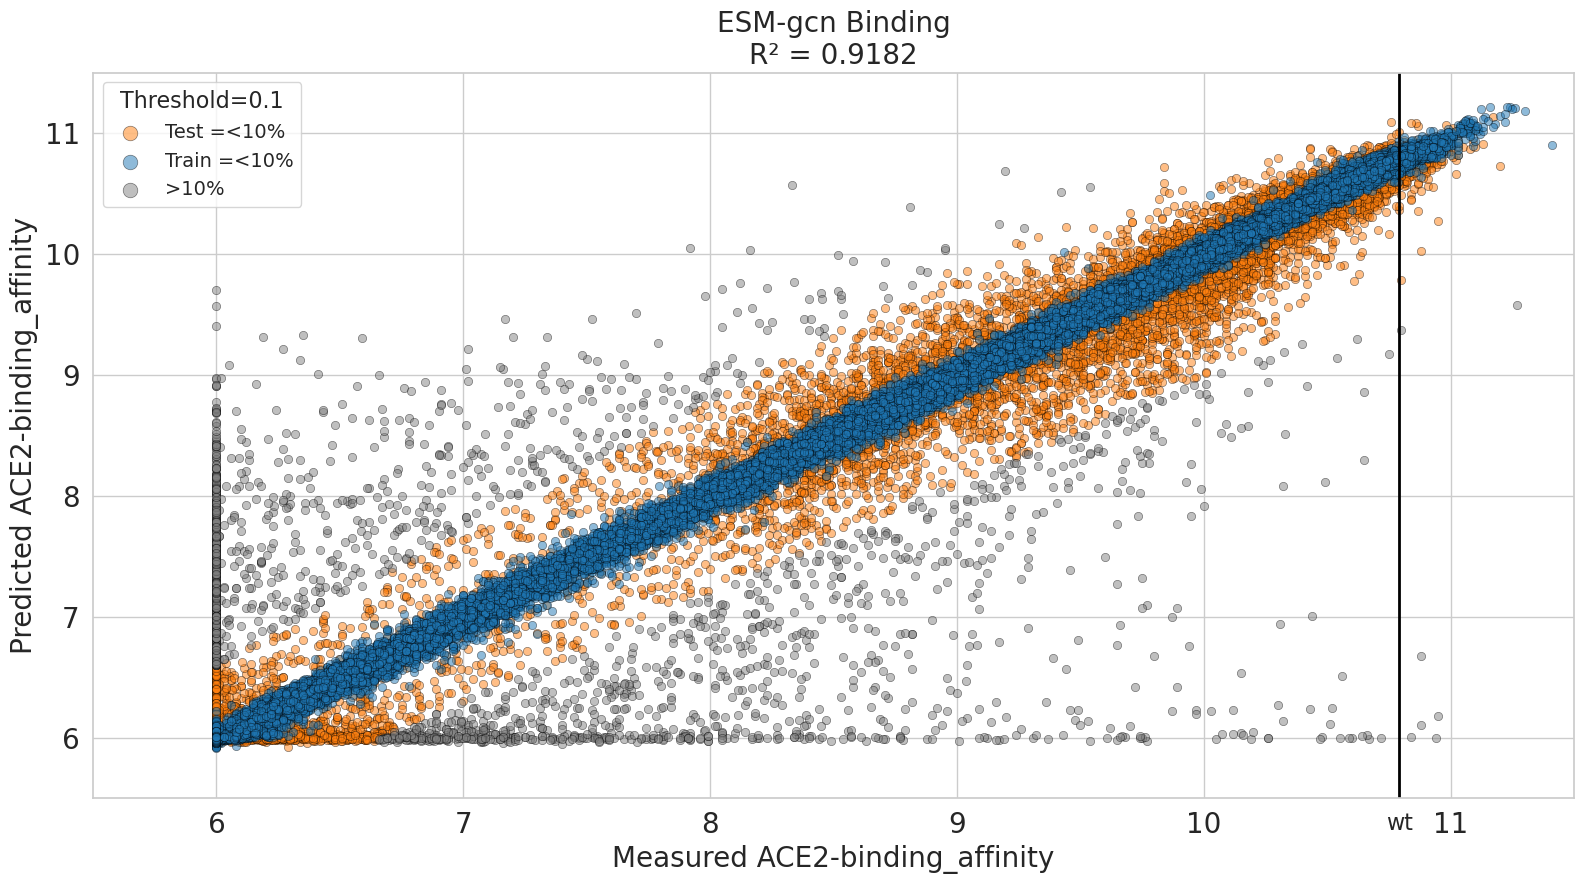

R^2: 0.8884354603907051
R^2 outside of threshold: -0.42996209163246646
R^2 inside of threshold: 0.921262778640759


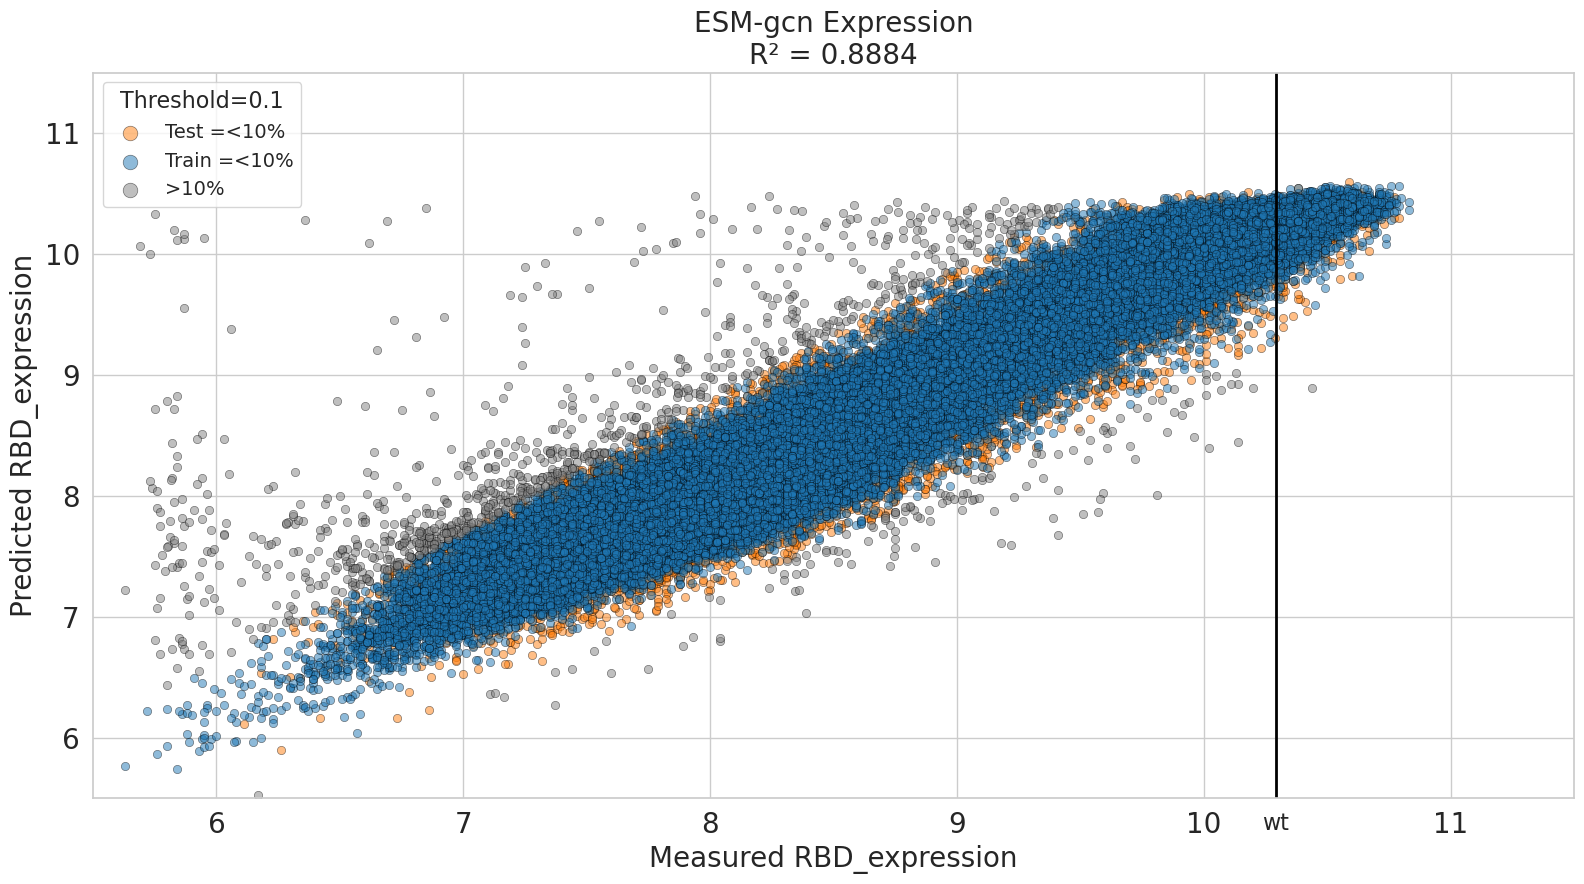

In [16]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-gcn Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn.lr1e-05.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-gcn Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn.lr1e-05.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-04

R^2: 0.9221514547604707
R^2 outside of threshold: -0.7167913734071094
R^2 inside of threshold: 0.9880382532291294


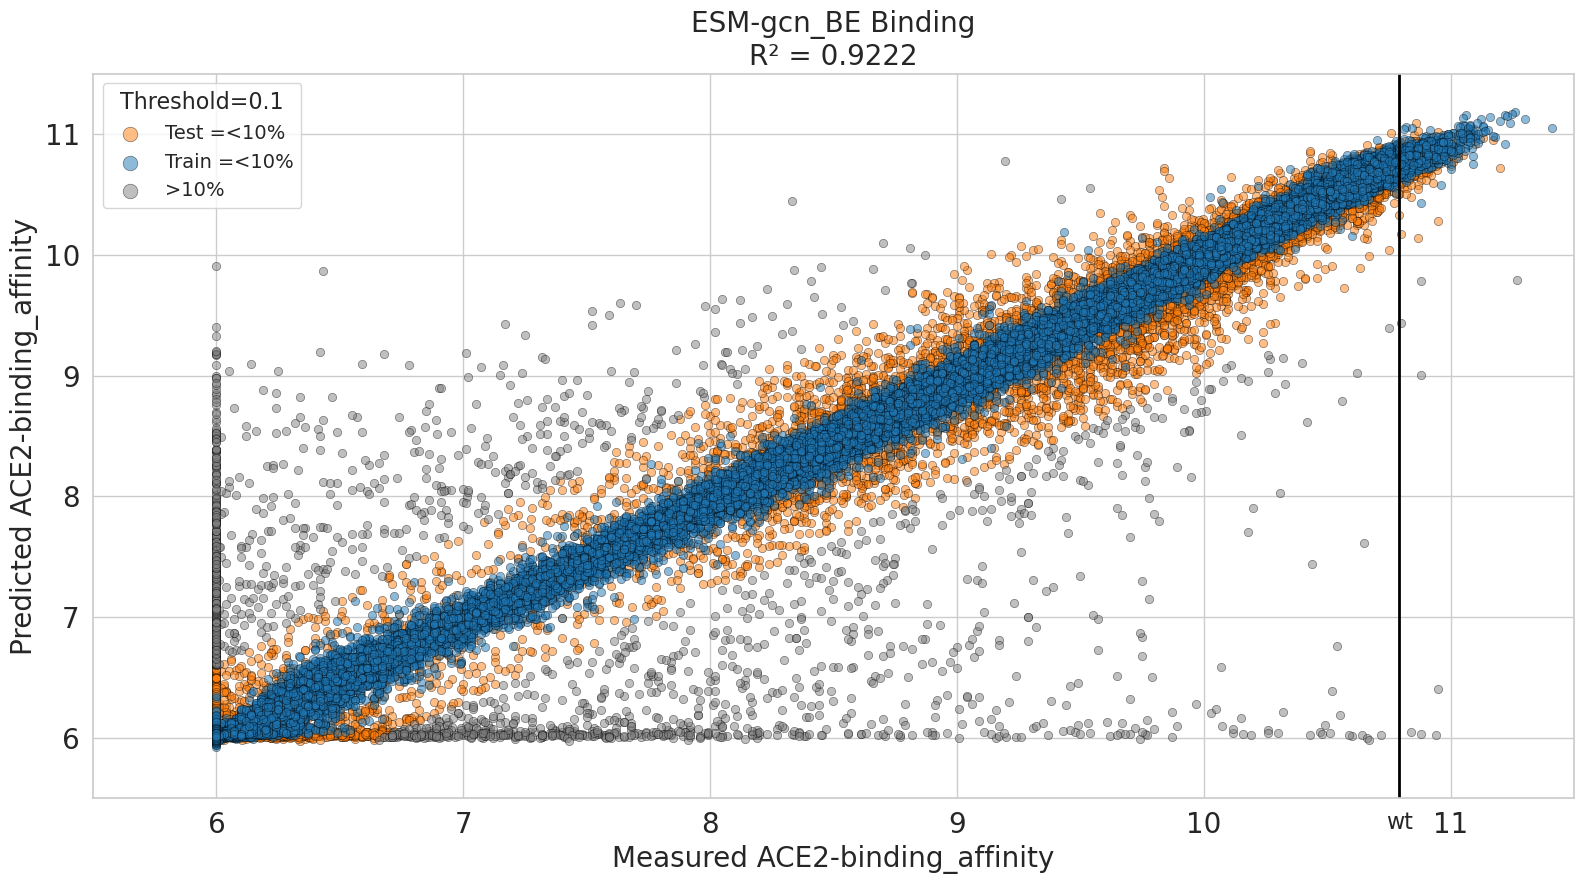

R^2: 0.8906016809742289
R^2 outside of threshold: -0.09032297013685264
R^2 inside of threshold: 0.9187605278570993


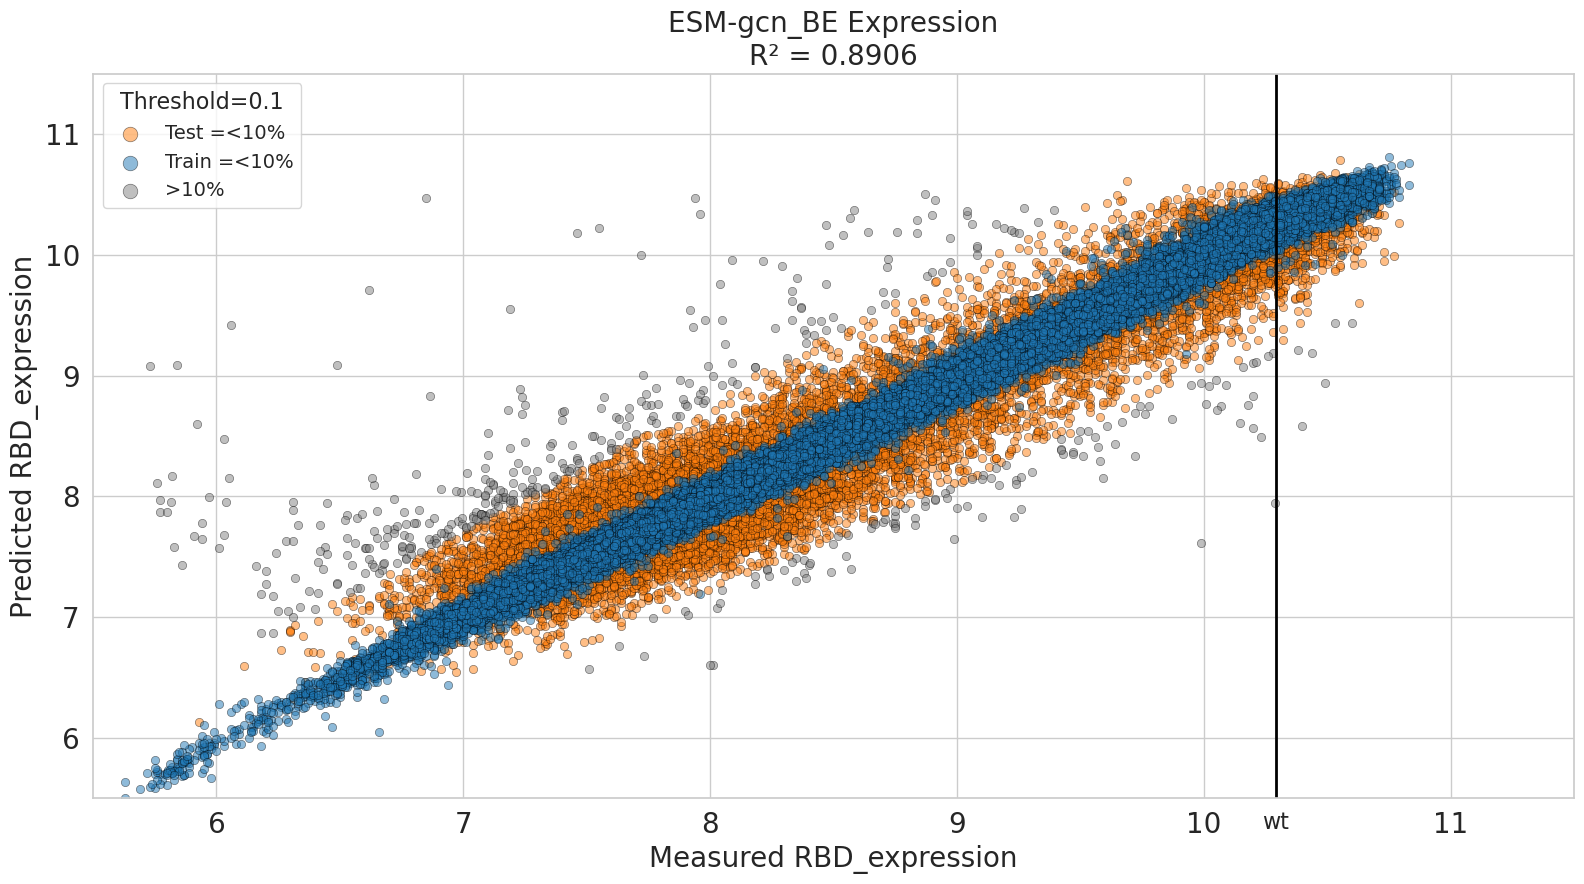

In [17]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr0.0001.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_be_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-gcn_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn_be.lr1e-04.binding-scatter.pdf", binding_wt)
esm_gcn_be_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-gcn_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn_be.lr1e-04.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-05

R^2: 0.9189310404489809
R^2 outside of threshold: -0.45293929838920133
R^2 inside of threshold: 0.9857642884309455


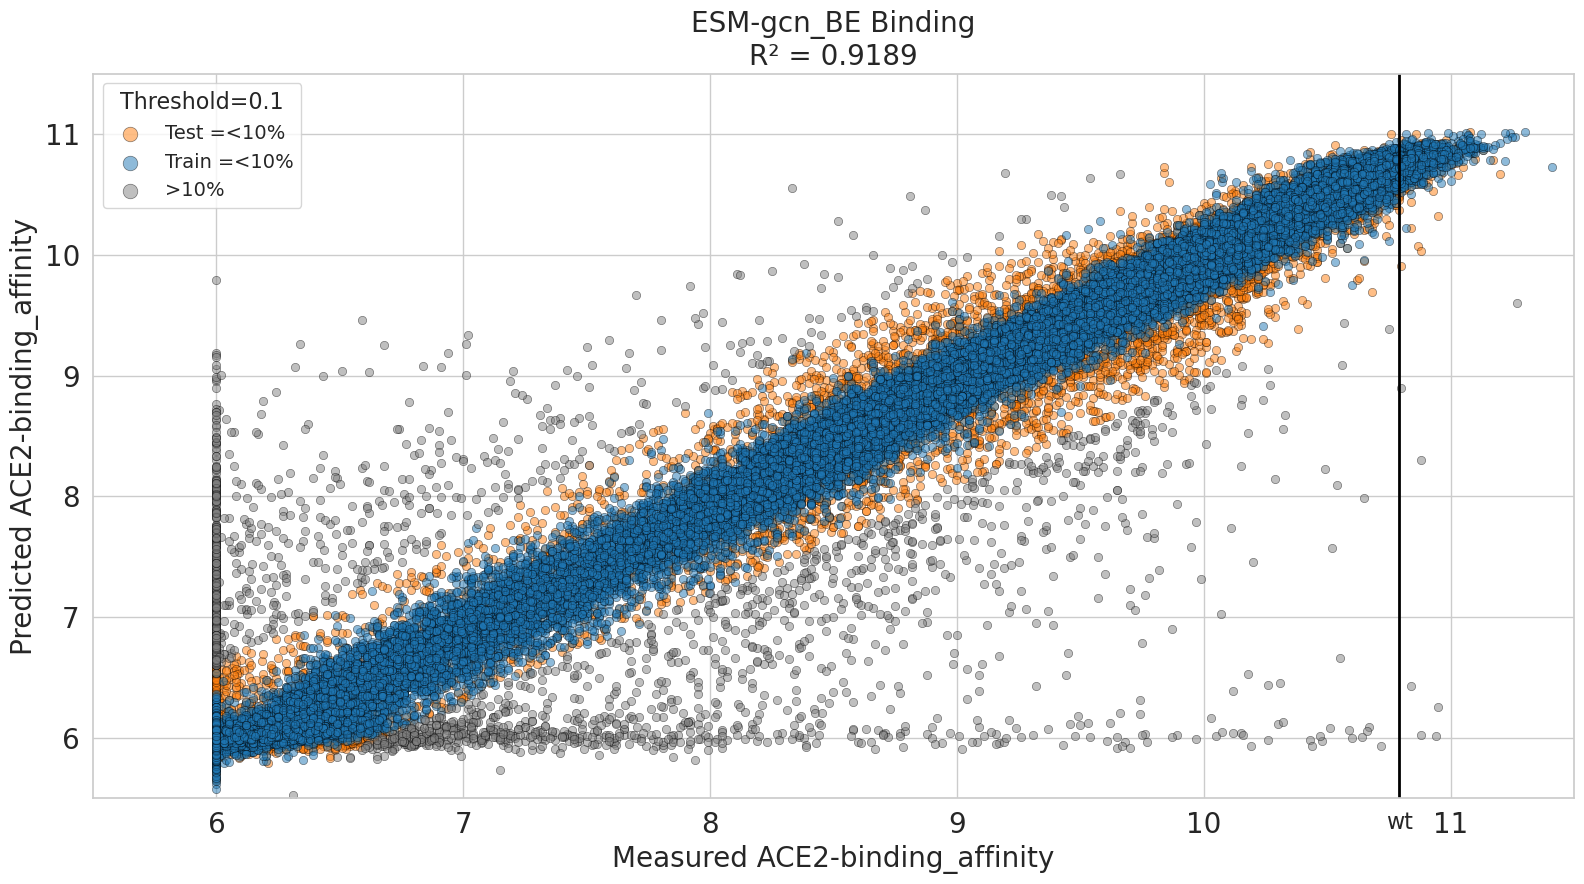

R^2: 0.8617753374051622
R^2 outside of threshold: -0.19201430487107696
R^2 inside of threshold: 0.9012017423733868


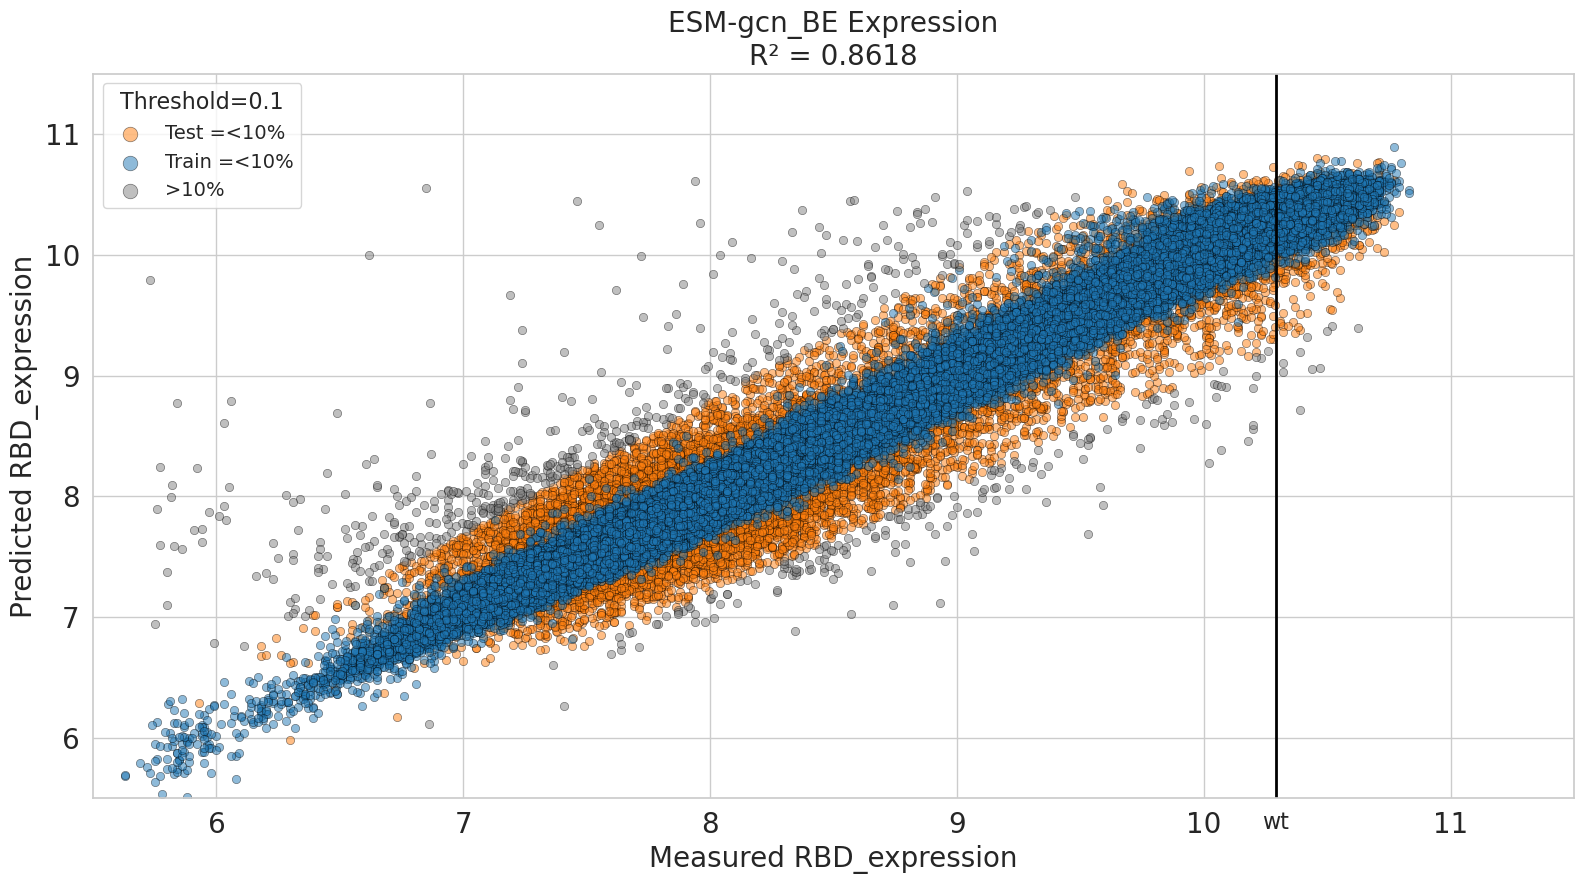

In [18]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_be_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-gcn_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn_be.lr1e-05.binding-scatter.pdf", binding_wt)
esm_gcn_be_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-gcn_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn_be.lr1e-05.expression-scatter.pdf", expression_wt)

### Bar Chart

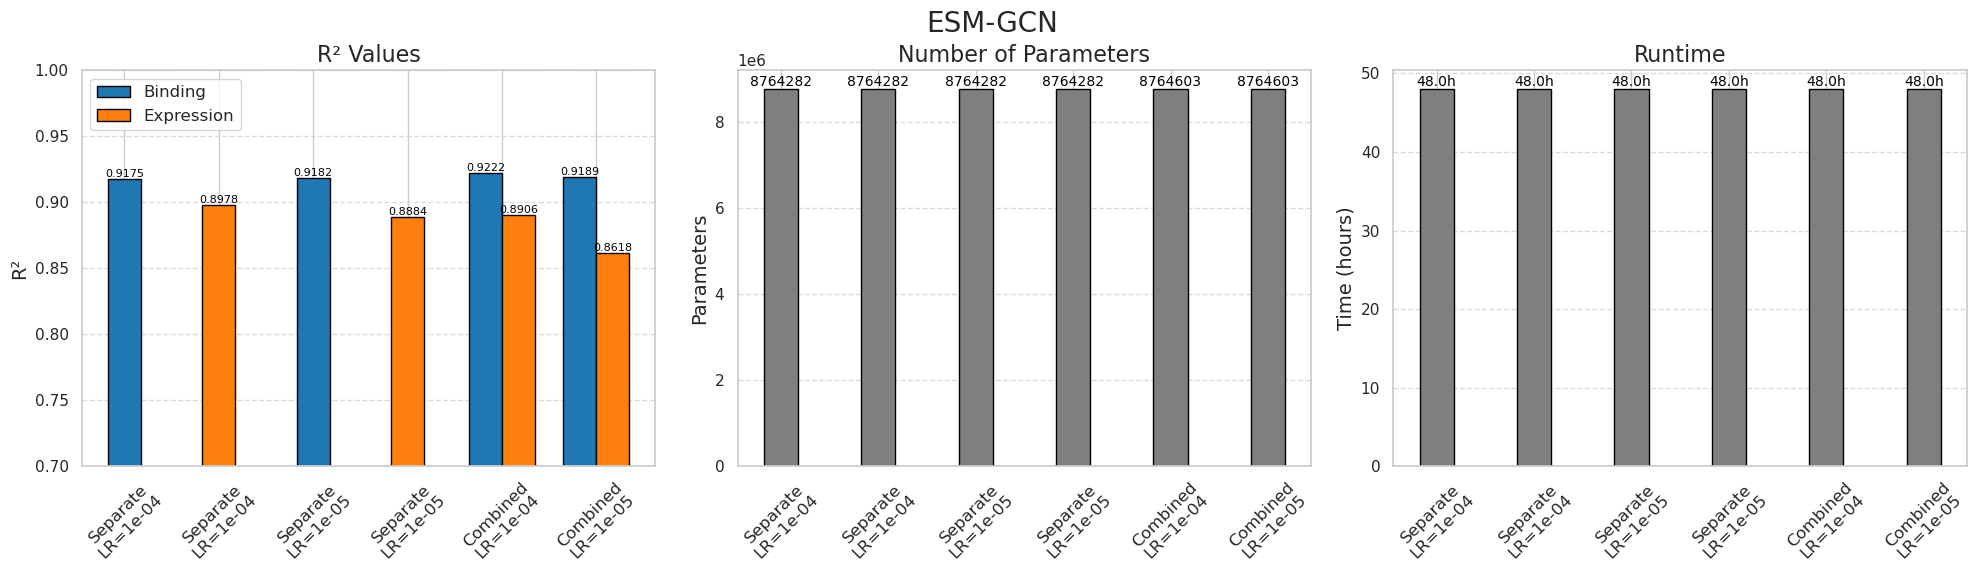

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Data
r2_dict = {
    "Separate\nLR=1e-04.binding": esm_gcn_lr1e_04_binding,
    "Separate\nLR=1e-04.expression": esm_gcn_lr1e_04_expression,
    "Separate\nLR=1e-05.binding": esm_gcn_lr1e_05_binding,
    "Separate\nLR=1e-05.expression": esm_gcn_lr1e_05_expression,
    "Combined\nLR=1e-04.binding": esm_gcn_be_lr1e_04_binding,
    "Combined\nLR=1e-04.expression": esm_gcn_be_lr1e_04_expression,
    "Combined\nLR=1e-05.binding": esm_gcn_be_lr1e_05_binding,
    "Combined\nLR=1e-05.expression": esm_gcn_be_lr1e_05_expression
}

params_dict = {
    "Separate\nLR=1e-04.binding": 8764282,
    "Separate\nLR=1e-04.expression": 8764282,
    "Separate\nLR=1e-05.binding": 8764282,
    "Separate\nLR=1e-05.expression": 8764282,
    "Combined\nLR=1e-04.binding": 8764603,
    "Combined\nLR=1e-04.expression": 8764603,
    "Combined\nLR=1e-05.binding": 8764603,
    "Combined\nLR=1e-05.expression": 8764603
}

runtime_dict = {
    "Separate\nLR=1e-04.binding": "48:00:00",
    "Separate\nLR=1e-04.expression": "48:00:00",
    "Separate\nLR=1e-05.binding": "48:00:00",
    "Separate\nLR=1e-05.expression": "48:00:00",
    "Combined\nLR=1e-04.binding": "48:00:00",
    "Combined\nLR=1e-04.expression": "48:00:00",
    "Combined\nLR=1e-05.binding": "48:00:00",
    "Combined\nLR=1e-05.expression": "48:00:00"
}

def parse_extended_time(time_str):
    hours, minutes, seconds = map(int, time_str.split(':'))
    td = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    return td.total_seconds() / 3600  # Convert to hours

# Convert runtime dictionary to hours
runtime_hours = {k: parse_extended_time(v) for k, v in runtime_dict.items()}

# Separate models and combined models
separate_models = sorted([k for k in r2_dict.keys() if "Separate" in k])
combined_models = sorted(list(set([k.rsplit(".", 1)[0] for k in r2_dict.keys() if "Combined" in k])))

# X indices
x_inds_sep = np.arange(len(separate_models))
x_inds_comb = np.arange(len(combined_models)) + len(separate_models)

# Bar width
bar_width = 0.35

# Colors
binding_color = 'tab:blue'
expression_color = 'tab:orange'

# Figure setup
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² Plot
binding_legend = None
expression_legend = None

for i, model in enumerate(separate_models):
    color = binding_color if 'binding' in model else expression_color
    bar = axes[0].bar(x_inds_sep[i], r2_dict[model], color=color, edgecolor='black', width=bar_width)
    if 'binding' in model and binding_legend is None:
        binding_legend = bar
    elif 'expression' in model and expression_legend is None:
        expression_legend = bar

for i, model in enumerate(combined_models):
    binding_r2 = r2_dict[f"{model}.binding"]
    expression_r2 = r2_dict[f"{model}.expression"]
    axes[0].bar(x_inds_comb[i] - bar_width/2, binding_r2, color=binding_color, edgecolor='black', width=bar_width)
    axes[0].bar(x_inds_comb[i] + bar_width/2, expression_r2, color=expression_color, edgecolor='black', width=bar_width)

axes[0].set_title("R² Values", fontsize=16)
axes[0].set_ylabel("R²", fontsize=14)
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend([binding_legend, expression_legend], ["Binding", "Expression"], fontsize=12, loc="upper left")

# Parameters Plot
params_sep = [params_dict[m] for m in separate_models]
params_comb = [params_dict[f"{m}.binding"] for m in combined_models]

axes[1].bar(x_inds_sep, params_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].bar(x_inds_comb, params_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].set_title("Number of Parameters", fontsize=16)
axes[1].set_ylabel("Parameters", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Runtime Plot
runtime_sep = [runtime_hours[m] for m in separate_models]
runtime_comb = [runtime_hours[f"{m}.binding"] for m in combined_models]

axes[2].bar(x_inds_sep, runtime_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].bar(x_inds_comb, runtime_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].set_title("Runtime", fontsize=16)
axes[2].set_ylabel("Time (hours)", fontsize=14)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Common x-axis labels
all_labels = separate_models + combined_models
all_labels = [label.replace('.binding', '').replace('.expression', '') for label in all_labels]
for ax in axes:
    ax.set_xticks(list(x_inds_sep) + list(x_inds_comb))
    ax.set_xticklabels(all_labels, fontsize=12, rotation=45)

# Add value labels on bars
for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        if ax == axes[2]:  # Runtime plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.1f}h',
                   ha='center', va='bottom', fontsize=10, color='black')
        elif ax == axes[1]:  # Parameter plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height}',
                   ha='center', va='bottom', fontsize=10, color='black')
        else: # R2 plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.4f}',
                   ha='center', va='bottom', fontsize=8, color='black')
            
fig.suptitle("ESM-GCN", fontsize=20, y=.95)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_gcn-bar_comp.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

### Frequent Mutations
Histogram figure of frequent mutations. We'll choose the best performing models based on having positive R^2 values, then best RMSE.

In [76]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/double_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
predicted_df.rename(columns={'predicted_value': 'binding_predicted_value'}, inplace=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)

### Binding

In [78]:
# Binding
binding_df = merged_df[["seq_id", "binding_predicted_value", "ACE2-binding_affinity", "mode"]].copy()
binding_df["percentage_error"] = ((merged_df["binding_predicted_value"] - merged_df["ACE2-binding_affinity"]) / merged_df["ACE2-binding_affinity"]) * 100
binding_df

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-C102F_N118L,6.011733,6.000,train,0.195543
1,SARS-CoV-2-C6S_N120K,10.125878,10.115,train,0.107547
2,SARS-CoV-2-E10V_V20E_L57G_G83L_D98P_I104E_A145...,6.018019,6.000,train,0.300312
3,SARS-CoV-2-S36L_Y50F_G83S_G86N_C150S,6.005737,6.000,train,0.095622
4,SARS-CoV-2-E186H,10.694951,10.730,train,-0.326644
...,...,...,...,...,...
102718,SARS-CoV-2-N58I_A81L_R136M_I142M,6.006166,6.000,test,0.102774
102719,SARS-CoV-2-G51V_Y93Q_Y143C,6.011636,6.000,test,0.193930
102720,SARS-CoV-2-I28A_S41N_C49W_C61N_K94A_F160G_N171Y,6.032571,6.000,test,0.542855
102721,SARS-CoV-2-N13L_Y91A_T100K_A105N,6.205151,6.000,test,3.419177


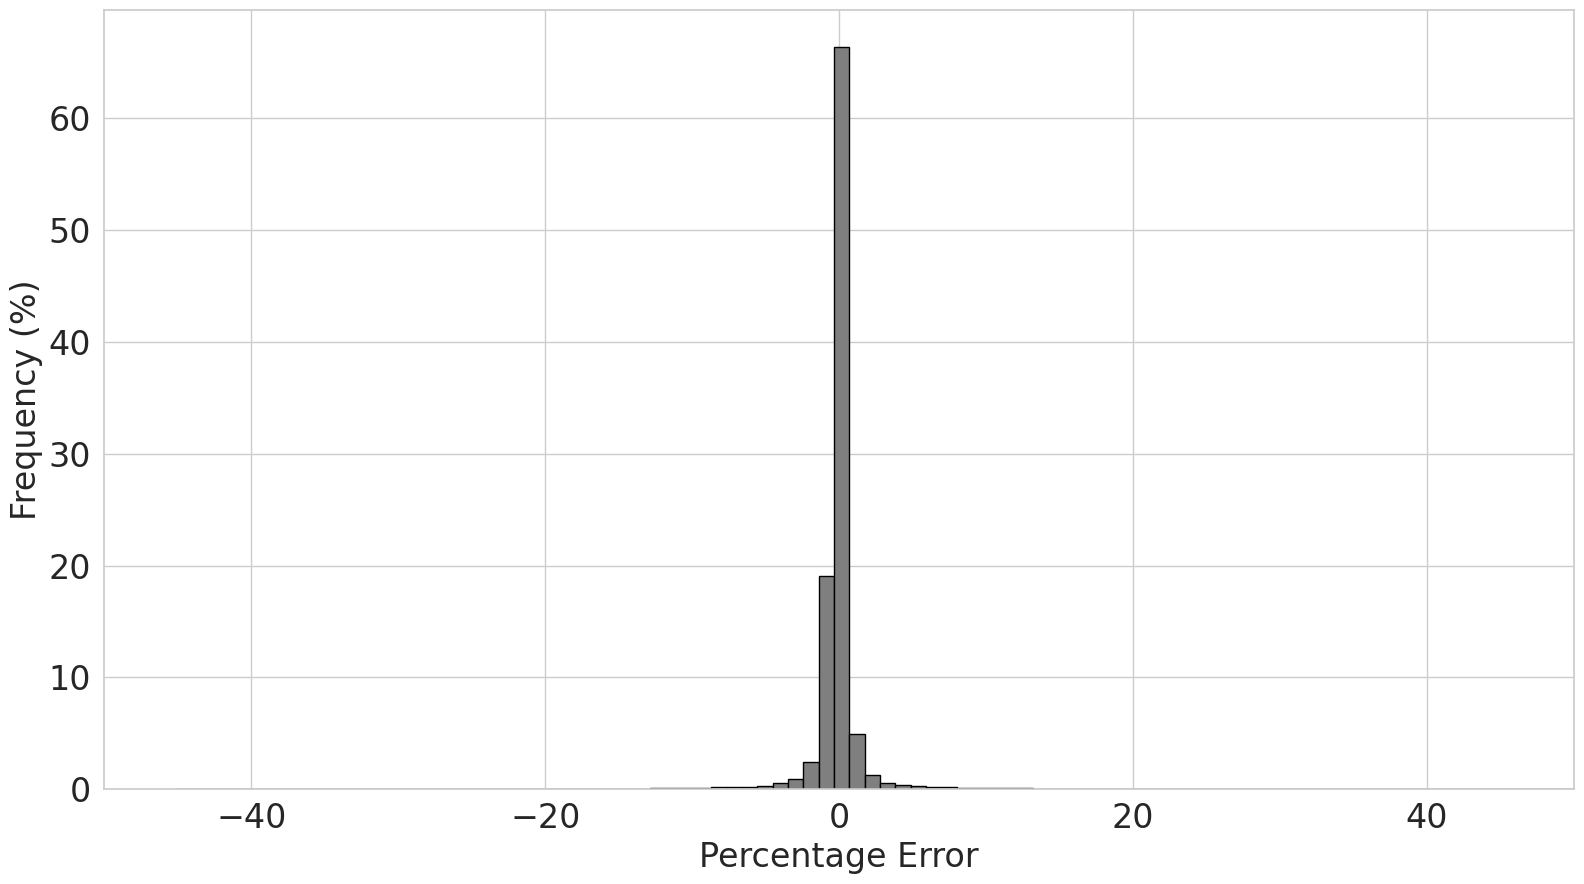

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    binding_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(binding_df)] * len(binding_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/scatter/esm_gcn.2r.lr1e-05.binding-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

Now let's pull the outliers from top and bottom 2.5%.

In [80]:
lower_bound = binding_df['percentage_error'].quantile(0.025)
upper_bound = binding_df['percentage_error'].quantile(0.975)

outliers = binding_df[(binding_df['percentage_error'] < lower_bound) | (binding_df['percentage_error'] > upper_bound)].reset_index(drop=True)
outliers

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-F17E_D34N_Y143K,6.568155,6.81,train,-3.551324
1,SARS-CoV-2-Y50K_I72T_F134L,7.930748,8.36,train,-5.134593
2,SARS-CoV-2-L5S_L131G_P177C,6.777655,6.41,train,5.735649
3,SARS-CoV-2-F12E_D97I_G116S,6.934258,7.22,train,-3.957646
4,SARS-CoV-2-S139R_F167L,7.500996,7.18,train,4.470691
...,...,...,...,...,...
5133,SARS-CoV-2-R73K_D90M_Y159L_S200R,7.108182,8.30,test,-14.359254
5134,SARS-CoV-2-F70L_I104Q_L125T_P133N_T140R_V173A_...,6.011795,7.88,test,-23.708191
5135,SARS-CoV-2-S36I_S53R_K87N_W106F,9.165755,8.60,test,6.578550
5136,SARS-CoV-2-D137W_V173K,8.098465,8.50,test,-4.723942


We need to adjust the seq_id to acquire the mutations from the data. 

The Spike receptor binding domain (RBD) from SARS-CoV-2 (isolate Wuhan-Hu-1, GenBank : MN908947, residues N331-T531) (checked [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.cell.com/cell/fulltext/S0092-8674(20)31003-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867420310035%3Fshowall%3Dtrue)). So we need to add 330 to get the RBD site (data not 0 indexed).

In [81]:
df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(10)

5138
16907


,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-F17E_D34N_Y143K,6.568155,6.81,train,-3.551324,SARS-CoV-2,F17E,347,F,E,F>E
0,SARS-CoV-2-F17E_D34N_Y143K,6.568155,6.81,train,-3.551324,SARS-CoV-2,D34N,364,D,N,D>N
0,SARS-CoV-2-F17E_D34N_Y143K,6.568155,6.81,train,-3.551324,SARS-CoV-2,Y143K,473,Y,K,Y>K
1,SARS-CoV-2-Y50K_I72T_F134L,7.930748,8.36,train,-5.134593,SARS-CoV-2,Y50K,380,Y,K,Y>K
1,SARS-CoV-2-Y50K_I72T_F134L,7.930748,8.36,train,-5.134593,SARS-CoV-2,I72T,402,I,T,I>T
1,SARS-CoV-2-Y50K_I72T_F134L,7.930748,8.36,train,-5.134593,SARS-CoV-2,F134L,464,F,L,F>L
2,SARS-CoV-2-L5S_L131G_P177C,6.777655,6.41,train,5.735649,SARS-CoV-2,L5S,335,L,S,L>S
2,SARS-CoV-2-L5S_L131G_P177C,6.777655,6.41,train,5.735649,SARS-CoV-2,L131G,461,L,G,L>G
2,SARS-CoV-2-L5S_L131G_P177C,6.777655,6.41,train,5.735649,SARS-CoV-2,P177C,507,P,C,P>C
3,SARS-CoV-2-F12E_D97I_G116S,6.934258,7.22,train,-3.957646,SARS-CoV-2,F12E,342,F,E,F>E


Here we will look at the total mutations possible that occur at a particular site across all seq_ids in our outliers. Then we will break it down by amino acid.

In [82]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 93, 332: 140, 333: 118, 334: 97, 335: 165, 336: 164, 337: 84, 338: 85, 339: 181, 340: 99, 341: 80, 342: 128, 343: 94, 344: 154, 345: 107, 346: 65, 347: 68, 348: 46, 349: 86, 350: 52, 351: 42, 352: 57, 353: 76, 354: 39, 355: 52, 356: 49, 357: 81, 358: 76, 359: 33, 360: 25, 361: 48, 362: 40, 363: 112, 364: 105, 365: 138, 366: 80, 367: 122, 368: 93, 369: 86, 370: 71, 371: 156, 372: 96, 373: 87, 374: 137, 375: 129, 376: 55, 377: 47, 378: 69, 379: 117, 380: 88, 381: 103, 382: 49, 383: 42, 384: 73, 385: 129, 386: 123, 387: 76, 388: 72, 389: 88, 390: 116, 391: 212, 392: 71, 393: 90, 394: 111, 395: 42, 396: 42, 397: 34, 398: 77, 399: 58, 400: 31, 401: 36, 402: 30, 403: 46, 404: 34, 405: 24, 406: 47, 407: 95, 408: 40, 409: 10, 410: 22, 411: 89, 412: 98, 413: 146, 414: 99, 415: 90, 416: 158, 417: 150, 418: 66, 419: 139, 420: 233, 421: 156, 422: 49, 423: 58, 424: 114, 425: 116, 426: 127, 427: 159, 428: 151, 429: 139, 430: 149, 431: 46, 432: 47, 433: 139, 434: 109, 

Let's make this into a proper table. 

In [83]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
print(possible_mutations_per_site.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      331                   N                        93                  S(12), L(11), I(7), K(7), W(6), R(6), P(6), E(5), V(5), H(4), Y(4), T(4), M(4), G(4), Q(4), D(2), A(1), F(1)
      332                   I                       140         S(17), T(15), L(14), R(13), N(10), V(8), F(8), A(8), E(6), K(6), G(5), W(5), M(4), P(4), D(4), Y(4), C(3), H(3), Q(3)
      333                   T                       118           S(15), N(11), L(10), K(9), F(7), W(7), P(7), C(7), V(6), E(6), A(5), I(5), R(5), G(4), D(4), Y(4), H(3), M(2), Q(1)
      334                   N                        97                  L(15), P(10), S(9), K(7), I(7), R(7), M(6), T(6), F(5), Y(5), C(4), V(4), G(3), E(2), H(2), D(2), Q(2), W(1)
      335                   L                       165     Y(13), R(13), A(12), P(12), K(

Let's take a look at the top 10 sites with the highest total possible mutations occuring at that spot.

In [84]:
# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      531                   T                       252 R(27), L(24), M(23), S(23), K(21), V(15), I(14), Q(13), N(12), P(12), W(11), A(10), Y(10), E(8), G(7), F(6), D(6), C(5), H(5)
      420                   D                       233         S(29), Y(23), R(21), L(19), I(18), N(16), T(14), V(14), F(11), H(10), A(10), E(9), G(8), M(7), Q(6), W(6), C(6), K(6)
      391                   C                       212  T(19), K(19), L(17), V(16), S(14), A(14), F(14), R(13), H(11), M(10), Y(10), P(10), G(8), N(8), I(8), E(7), D(6), W(4), Q(4)
      436                   W                       205      R(30), L(25), V(21), S(16), T(16), G(10), I(10), K(10), C(8), M(8), A(8), N(8), E(7), Q(7), D(7), Y(6), F(4), P(3), H(1)
      435                   A                       189        T(20), S(19), L(18), V(17),

Now, for each site we will grab the top 10 (as available) "binding_predicted_value" scores for each site. And then we will find the highest score predicted score per site. We save the measured value "ACE2-binding_affinity", and we can use this as a coordinate value associated with it's percentage error.

In [85]:
# Group by 'RBD_mutation_site' and extract top 10 binding_predicted_value scores for each site
top_p_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x.nlargest(10, 'binding_predicted_value')[['new_aa', 'ACE2-binding_affinity', 'binding_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest binding_predicted_value score for each site
highest_p_scores = {site: max(scores, key=lambda x: x[2])[2] if scores else 0 for site, scores in top_p_scores_dict.items()}

data = []
for site, max_score in highest_p_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = top_p_scores_dict.get(site, [])
    scores_str = ', '.join([f'{aa}(({m_score:.2f}, {p_score:.2f}), {perc_error:.2f}%)' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest Predicted Binding Value': f'{max_score:.2f}',
        'Measured and Predicted Binding Values ((m, p), %_err)': scores_str
    })

top_10_scores_per_site = pd.DataFrame(data)
print(top_10_scores_per_site.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest Predicted Binding Value                                                                                                                                                                                                             Measured and Predicted Binding Values ((m, p), %_err)
      331               93                   N                           10.78        T((11.20, 10.78), -3.79%), D((10.37, 10.68), 3.03%), L((10.08, 10.61), 5.25%), S((9.39, 10.03), 6.82%), H((9.59, 9.99), 4.13%), S((10.29, 9.63), -6.39%), R((8.94, 9.54), 6.76%), L((9.87, 9.41), -4.70%), S((9.79, 9.40), -4.01%), G((8.95, 9.39), 4.93%)
      332              140                   I                           10.58          S((10.26, 10.58), 3.10%), E((10.13, 10.54), 4.09%), S((9.80, 10.13), 3.40%), C((9.75, 10.12), 3.77%), R((9.57, 9.92), 3.66%), F((8.88, 9.91), 11.55%), P((9.52, 9.89), 3.92%), F((9.42, 9.84), 4.41%), R((10.19, 9.78), -3.98%), G((9.99, 9.54

Top 10.

In [86]:
# Sort and display the top 10
top_10_scores_per_site['Highest Predicted Binding Value'] = pd.to_numeric(top_10_scores_per_site['Highest Predicted Binding Value'])
top_10_highest = top_10_scores_per_site.sort_values('Highest Predicted Binding Value', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest Predicted Binding Value                                                                                                                                                                                                             Measured and Predicted Binding Values ((m, p), %_err)
      384               73                   P                            10.88   I((10.43, 10.88), 4.27%), L((10.43, 10.83), 3.84%), Y((10.28, 10.67), 3.82%), H((10.09, 10.41), 3.17%), R((10.69, 10.30), -3.65%), F((10.12, 9.74), -3.75%), G((9.27, 9.59), 3.51%), L((10.13, 9.55), -5.73%), F((8.37, 9.50), 13.50%), D((6.00, 9.33), 55.54%)
      503              132                   V                            10.88 I((10.43, 10.88), 4.27%), L((9.84, 10.71), 8.88%), N((9.19, 10.66), 15.98%), F((10.79, 10.35), -4.11%), E((9.78, 10.30), 5.28%), K((10.66, 10.18), -4.53%), C((10.51, 10.07), -4.20%), S((10.17, 9.81), -3.50%), D((10.17, 9.81), -3.58%), T((9.45, 

In [87]:
sorted(top_10_highest['RBD Site'].to_list())

[335, 366, 384, 394, 452, 462, 471, 490, 503, 527]